 Industrial Data Analysis


Step 1 — Connect Google Drive

In [ ]:
from google.colab import drive # code to access google drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# STEP 0 — Imports
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

BASE_PATH = "/content/gdrive/MyDrive/Industrial Data Analysis"

TRAIN_DIR = os.path.join(BASE_PATH, "train")
TEST_DIR  = os.path.join(BASE_PATH, "test")
MASK_DIR  = os.path.join(BASE_PATH, "mask")

train_files = sorted([os.path.join(TRAIN_DIR, f) for f in os.listdir(TRAIN_DIR) if f.endswith(".npy")])
test_files  = sorted([os.path.join(TEST_DIR, f)  for f in os.listdir(TEST_DIR)  if f.endswith(".npy")])
mask_files  = sorted([os.path.join(MASK_DIR, f)  for f in os.listdir(MASK_DIR)  if f.endswith(".npy")])


In [ ]:

print("Train files:", len(train_files))
print("Test files:", len(test_files))
print("Mask files:", len(mask_files))

# STEP 1 — Load signal + mask (ALIGN FIRST)
signal = np.load(train_files[0])
mask   = np.load(mask_files[0]).astype(int).flatten()

# Align lengths
min_len = min(len(signal), len(mask))
signal = signal[:min_len]
mask   = mask[:min_len]


Train files: 9
Test files: 9
Mask files: 9


In [ ]:


# ✅ No indexing error possible after this

# STEP 2 — Windowing (single source of truth)
WINDOW = 128
STRIDE = 16

def create_windows(signal, mask, window, stride):
    X, y = [], []
    for i in range(0, len(signal) - window + 1, stride):
        X.append(signal[i:i+window])
        y.append(1 if np.any(mask[i:i+window]) else 0)
    return np.array(X), np.array(y)

X_all, y_all = create_windows(signal, mask, WINDOW, STRIDE)


In [ ]:


# ✔ X_all.shape[0] == y_all.shape[0] ALWAYS

# STEP 3 — Train ONLY on normal windows (VAE rule)
X_train = X_all[y_all == 0]

In [ ]:


# STEP 4 — Scaling (fit on normal only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, WINDOW)).reshape(-1, WINDOW)
X_all_scaled   = scaler.transform(X_all.reshape(-1, WINDOW)).reshape(-1, WINDOW)

In [ ]:

# STEP 5 — Torch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_all_t   = torch.tensor(X_all_scaled,   dtype=torch.float32)

In [ ]:
# STEP 6 — VAE model (minimal & stable)
class VAE(nn.Module):
    def __init__(self, input_dim=128, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU()
        )
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

In [ ]:
# STEP 7 — Train VAE (NO LABELS)
model = VAE(WINDOW, 8)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def vae_loss(x, recon, mu, logvar):
    recon_loss = torch.mean((x - recon) ** 2)
    kl = -0.5 * torch.mean(1 + logvar - mu**2 - torch.exp(logvar))
    return recon_loss + 0.001 * kl

loader = DataLoader(TensorDataset(X_train_t), batch_size=64, shuffle=True)

for epoch in range(50):
    model.train()
    loss_sum = 0
    for (x,) in loader:
        recon, mu, logvar = model(x)
        loss = vae_loss(x, recon, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
    print(f"Epoch {epoch:02d} | Loss: {loss_sum/len(loader):.4f}")




Epoch 00 | Loss: 0.5452
Epoch 01 | Loss: 0.1589
Epoch 02 | Loss: 0.1494
Epoch 03 | Loss: 0.1421
Epoch 04 | Loss: 0.1243
Epoch 05 | Loss: 0.1137
Epoch 06 | Loss: 0.1105
Epoch 07 | Loss: 0.1085
Epoch 08 | Loss: 0.1049
Epoch 09 | Loss: 0.1007
Epoch 10 | Loss: 0.0981
Epoch 11 | Loss: 0.0963
Epoch 12 | Loss: 0.0951
Epoch 13 | Loss: 0.0944
Epoch 14 | Loss: 0.0936
Epoch 15 | Loss: 0.0931
Epoch 16 | Loss: 0.0912
Epoch 17 | Loss: 0.0900
Epoch 18 | Loss: 0.0885
Epoch 19 | Loss: 0.0874
Epoch 20 | Loss: 0.0864
Epoch 21 | Loss: 0.0856
Epoch 22 | Loss: 0.0844
Epoch 23 | Loss: 0.0835
Epoch 24 | Loss: 0.0827
Epoch 25 | Loss: 0.0818
Epoch 26 | Loss: 0.0813
Epoch 27 | Loss: 0.0805
Epoch 28 | Loss: 0.0798
Epoch 29 | Loss: 0.0790
Epoch 30 | Loss: 0.0784
Epoch 31 | Loss: 0.0779
Epoch 32 | Loss: 0.0774
Epoch 33 | Loss: 0.0767
Epoch 34 | Loss: 0.0764
Epoch 35 | Loss: 0.0757
Epoch 36 | Loss: 0.0756
Epoch 37 | Loss: 0.0748
Epoch 38 | Loss: 0.0748
Epoch 39 | Loss: 0.0741
Epoch 40 | Loss: 0.0740
Epoch 41 | Loss:

In [ ]:


# STEP 8 — Reconstruction error (ALL windows)
model.eval()
with torch.no_grad():
    recon, _, _ = model(X_all_t)
    errors = torch.mean((X_all_t - recon) ** 2, dim=1).numpy()

In [ ]:
# STEP 9 — Threshold (percentile, correct)
threshold = np.percentile(errors[y_all == 0], 90)
y_pred = (errors > threshold).astype(int)

In [ ]:
# STEP 10 — Metrics (ALIGNED, NO ERRORS)
print("Precision:", precision_score(y_all, y_pred))
print("Recall:   ", recall_score(y_all, y_pred))
print("F1-score: ", f1_score(y_all, y_pred))
print("ROC-AUC:  ", roc_auc_score(y_all, errors))

Precision: 0.43155452436194897
Recall:    0.11654135338345864
F1-score:  0.18352244696595954
ROC-AUC:   0.5439741056769426


A) WINDOW-LEVEL RECONSTRUCTION ERROR (CRITICAL)
Add after computing errors and threshold

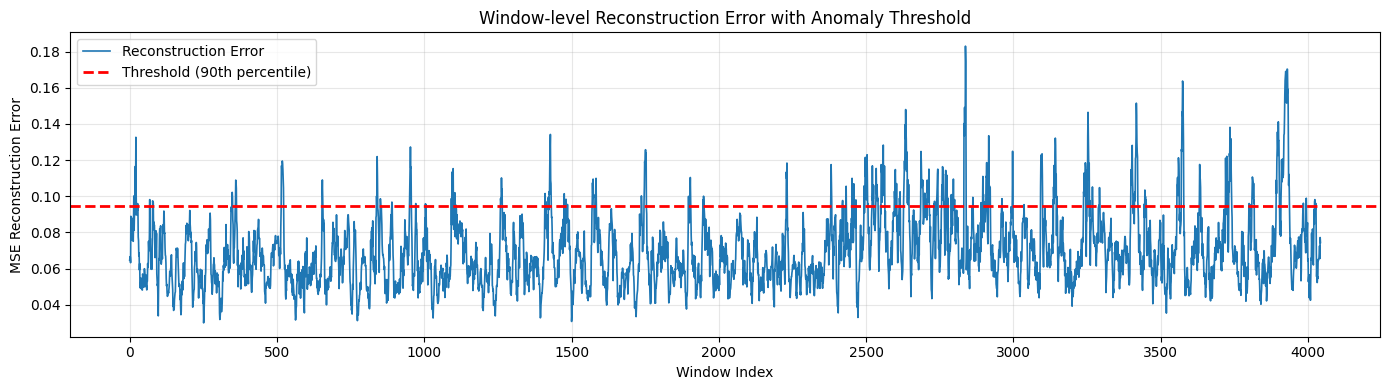

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(errors, linewidth=1.2, label="Reconstruction Error")
plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold (90th percentile)"
)
plt.xlabel("Window Index")
plt.ylabel("MSE Reconstruction Error")
plt.title("Window-level Reconstruction Error with Anomaly Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


B) SCORE DISTRIBUTION (THIS EXPLAINS ROC-AUC)

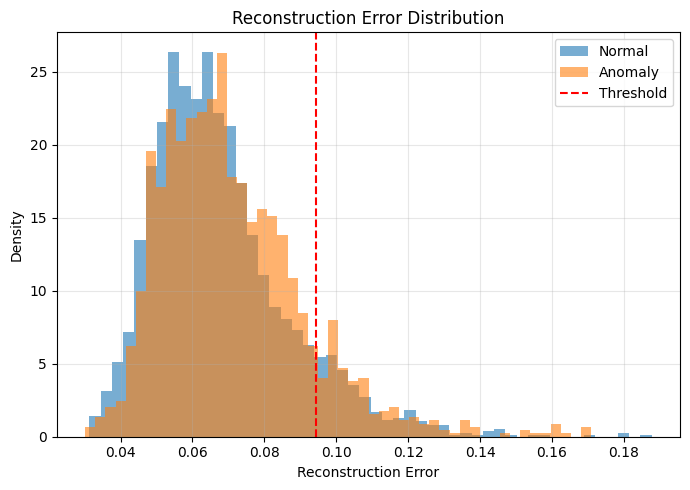

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(errors[y_all == 0], bins=50, alpha=0.6, label="Normal", density=True)
plt.hist(errors[y_all == 1], bins=50, alpha=0.6, label="Anomaly", density=True)

plt.axvline(threshold, color="red", linestyle="--", label="Threshold")

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


C) SIGNAL + DETECTED ANOMALY WINDOWS (MANDATORY)
Convert window predictions → time indices

In [ ]:
anomaly_windows = np.where(y_pred == 1)[0]

anomaly_points = []
for w in anomaly_windows:
    start = w * STRIDE
    end = start + WINDOW
    anomaly_points.extend(range(start, end))

anomaly_points = np.unique(anomaly_points)
anomaly_points = anomaly_points[anomaly_points < len(signal)]


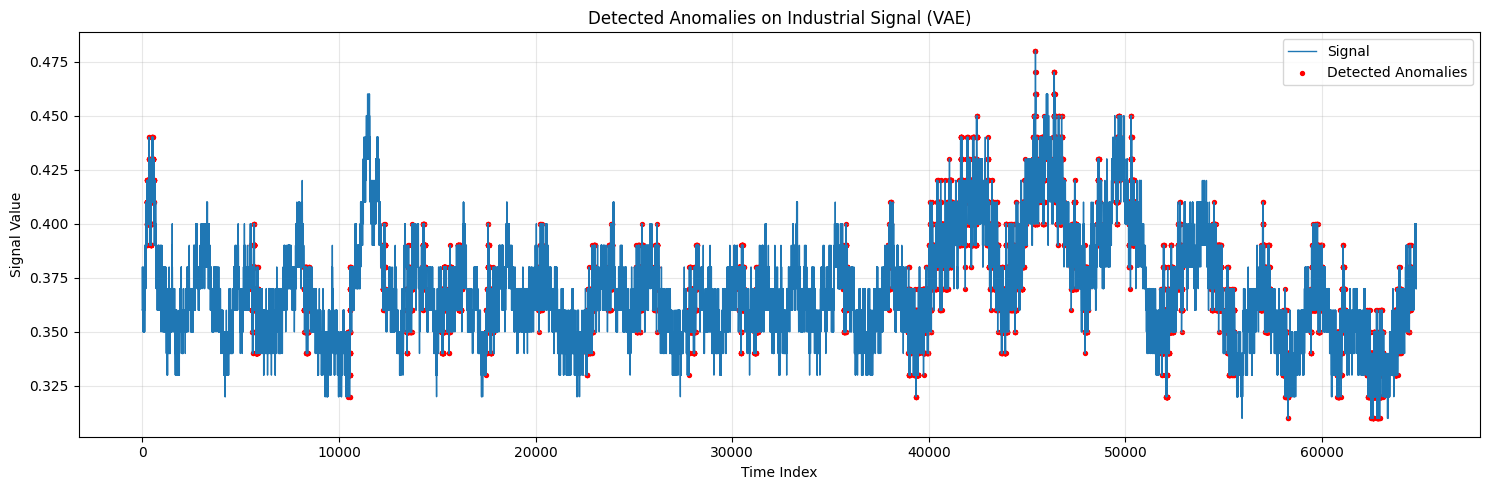

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(signal, linewidth=1, label="Signal")

plt.scatter(
    anomaly_points,
    signal[anomaly_points],
    s=8,
    color="red",
    label="Detected Anomalies"
)

plt.xlabel("Time Index")
plt.ylabel("Signal Value")
plt.title("Detected Anomalies on Industrial Signal (VAE)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


D) OPTIONAL: ROC CURVE (FOR COMPLETENESS)

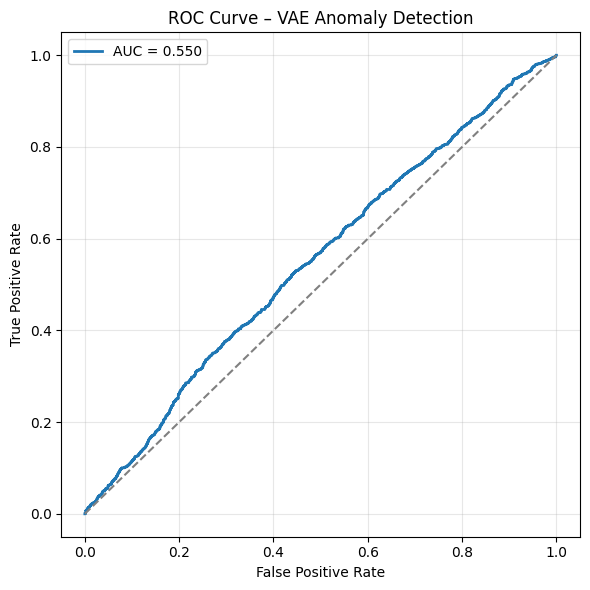

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_all, errors)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc_score(y_all, errors):.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – VAE Anomaly Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Overall Anomaly Coverage (Ground Truth vs Detected)

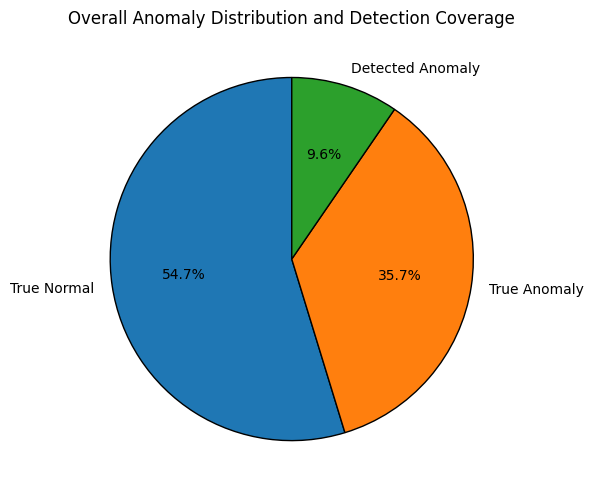

In [ ]:
# Ground truth anomaly ratio
gt_anomaly_ratio = y_all.mean()
detected_ratio = y_pred.mean()

labels = [
    "True Normal",
    "True Anomaly",
    "Detected Anomaly"
]

values = [
    1 - gt_anomaly_ratio,
    gt_anomaly_ratio,
    detected_ratio
]

plt.figure(figsize=(6,6))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black"}
)
plt.title("Overall Anomaly Distribution and Detection Coverage")
plt.tight_layout()
plt.show()


ISUALIZATION 2
Detection Outcome Breakdown (TP / FP / FN / TN)

Type: Stacked bar chart
Purpose: Shows what the model actually gets wrong

Why this is important

Reviewers love confusion-based visualizations because they show error structure, not just numbers.

Add after computing y_pred

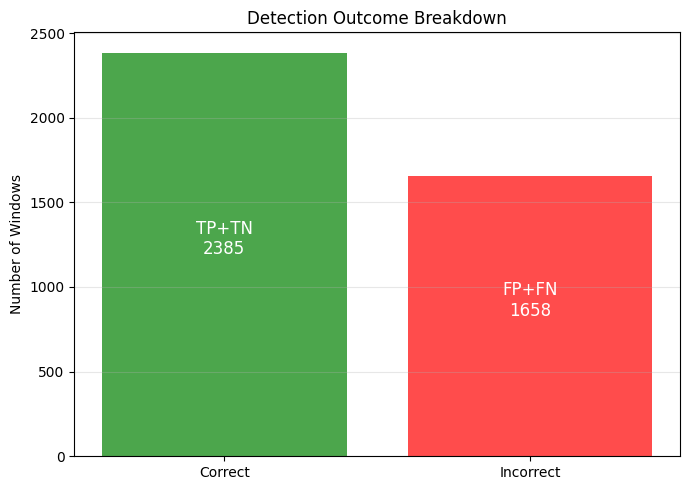

In [ ]:
TP = np.sum((y_all == 1) & (y_pred == 1))
FP = np.sum((y_all == 0) & (y_pred == 1))
FN = np.sum((y_all == 1) & (y_pred == 0))
TN = np.sum((y_all == 0) & (y_pred == 0))

plt.figure(figsize=(7,5))
plt.bar(
    ["Correct", "Incorrect"],
    [TP + TN, FP + FN],
    color=["green", "red"],
    alpha=0.7
)

plt.text(0, (TP+TN)/2, f"TP+TN\n{TP+TN}", ha="center", color="white", fontsize=12)
plt.text(1, (FP+FN)/2, f"FP+FN\n{FP+FN}", ha="center", color="white", fontsize=12)

plt.ylabel("Number of Windows")
plt.title("Detection Outcome Breakdown")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


VISUALIZATION 3
Error Evolution Over Time (Smoothed)

Type: Rolling mean line plot
Purpose: Shows when anomalies occur and how errors evolve temporally

Why this is unique

Goes beyond static thresholds

Shows temporal structure of faults

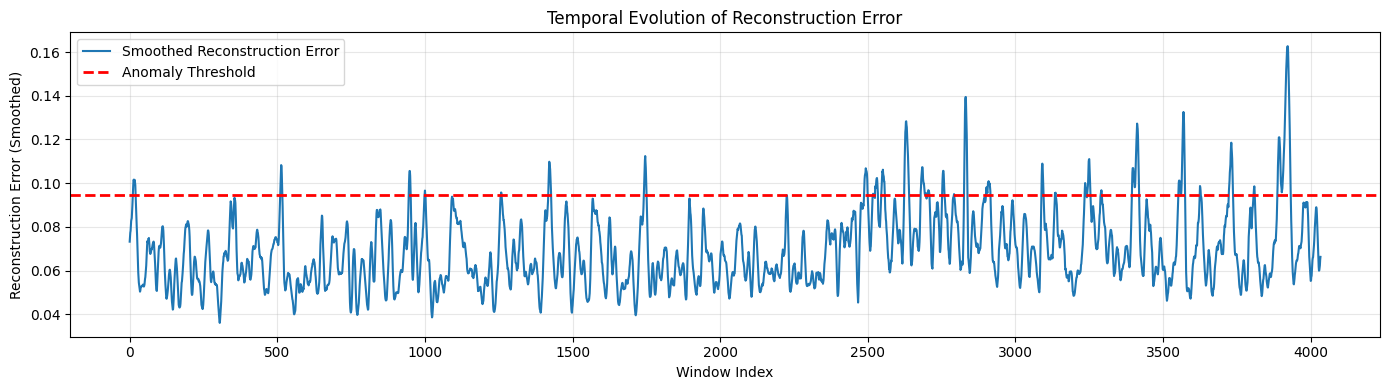

In [ ]:
# Smooth reconstruction error
window = 10
errors_smooth = np.convolve(
    errors,
    np.ones(window)/window,
    mode="valid"
)

plt.figure(figsize=(14,4))
plt.plot(errors_smooth, linewidth=1.5, label="Smoothed Reconstruction Error")

plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Anomaly Threshold"
)

plt.xlabel("Window Index")
plt.ylabel("Reconstruction Error (Smoothed)")
plt.title("Temporal Evolution of Reconstruction Error")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
